# Introduction

Outline:
* Explore YelpChi dataset
* Review evaluation metrics
* Detect anomalies using non-graph models

----------------------------------

TODO:
* Introduce graph statistics in the following notebook where graph algorithms are first discussed?
* Discuss metrics

In [166]:
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from ml_prague_2026.evaluation import compare_models, evaluate_model

In [139]:
YELP_CHI_PATH = "../data/yelpchi/yelpchi.parquet"

## Dataset

**YelpChi:**
* Collected from Yelp.com and first used by Mukherjee et al. [1]
* Originally included 67,395 reviews for a set of hotels and restaurants (201) in the Chicago area
* Filtered to 45,954 reviews by Dou et al. [2] for the purpose of graph anomally detection benchmarking
* Reviews include product and user information, timestamp, ratings, and a plaintext review
* Yelp has a filtering algorithm in place that identifies fake/suspicious reviews and separates them into a filtered list - marked as *spam*
* We consider spam reviews as anomalous and the other as benign/normal

[1] Mukherjee, Arjun, et al. ["Fake review detection: Classification and analysis of real and pseudo reviews."](https://www2.cs.uh.edu/~arjun/papers/UIC-CS-TR-yelp-spam.pdf) UIC-CS-03-2013. Technical Report. 2013.  
[2] Dou, Yingtong, et al. ["Enhancing graph neural network-based fraud detectors against camouflaged fraudsters."](https://arxiv.org/pdf/2008.08692) Proceedings of the 29th ACM international conference on information & knowledge management. 2020.

### Example - Product reviews

![yelp-chi-reviews.png](../presentation/images/yelp-chi-reviews.png)

### Example - Not recommended reviews

![yelp-chi-not-recommended.png](../presentation/images/yelp-chi-not-recommended.png)

### Data

In [145]:
# TASK 1: dataset format
# - what is the format of the data?
# - run the following cells
yelp_chi = pd.read_parquet(YELP_CHI_PATH)

In [147]:
yelp_chi.columns

Index(['date', 'review_id', 'user_id', 'product_id', 'spam', 'useful', 'funny',
       'cool', 'stars', 'review', 'f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'f_5',
       'f_6', 'f_7', 'f_8', 'f_9', 'f_10', 'f_11', 'f_12', 'f_13', 'f_14',
       'f_15', 'f_16', 'f_17', 'f_18', 'f_19', 'f_20', 'f_21', 'f_22', 'f_23',
       'f_24', 'f_25', 'f_26', 'f_27', 'f_28', 'f_29', 'f_30', 'f_31'],
      dtype='object')

In [148]:
FEATURES = [c for c in yelp_chi.columns if "f_" in c]

In [149]:
yelp_chi[[c for c in yelp_chi.columns if c not in FEATURES]].head(3)

,date,review_id,user_id,product_id,spam,useful,funny,cool,stars,review
0,2011-06-08,MyNjnxzZVTPq,IFTr6_6NI4CgCVavIL9k5g,tQfLGoolUMu2J0igcWcoZg,0,28,11,18,5,Let me begin by saying that there are two kind...
1,2011-08-30,BdD7fsPqHQL73hwENEDT-Q,c_-hF15XgNhlyy_TqzmdaA,tQfLGoolUMu2J0igcWcoZg,0,4,3,0,3,The only place inside the Loop that you can st...
2,2009-06-26,BfhqiyfC,CiwZ6S5ZizAFL5gypf8tLA,tQfLGoolUMu2J0igcWcoZg,0,23,14,12,5,I have walked by the Tokyo Hotel countless tim...


### Examples

In [152]:
for i, r in enumerate(yelp_chi[yelp_chi["spam"] == 1]["review"].sample(n=5)):
    print(f"Example #{i + 1}:")
    print(textwrap.fill(r, 80) + "\n")

Example #1:
This is the first churrascaria I have ever been to and I was totally blown away.
The restaurant is beautiful - it's massive in size and lavish in dcor with a
warm and inviting atmosphere. I immediately loved the color scheme of rich
rustic red. We were seated in the middle of the dining room, right in front of
the huge salad area and the wine room, which is really more like a glass wine
wall! Inside, a woman in a black leotard tumbled around on a wire system getting
bottles of wine while doing flips and spins, even stopping at one point to wave
and smile at us. I had never seen anything like it. The service was impeccable,
from our main server to the meat carvers to the managers who stopped by our
table to check in on us. While we were never left unattended when needed, the
service was not overkill, which is very important to me. Then there was the food
- lots and lots of it. We started at the salad and sushi bar and I loaded up on
everything from California rolls, to marin

### Review statistics

In [80]:
# TASK 2: spam reviews
# - what is the ratio of spam reviews? 
# - run this cell
yelp_chi["spam"].value_counts() / len(yelp_chi)

spam
0    0.854703
1    0.145297
Name: count, dtype: float64

### User behaviour

In [27]:
# TASK 3: spam users
# - what is the number of users?
# - run this cell
yelp_chi["user_id"].nunique()

29431

In [156]:
# TASK 3: spam users
# - what is the ratio of users producing spam?
# - mark users who produced at least one spam review using a new column "user_spam"
# - print ratio of spam users to all users

yelp_chi["user_spam"] = None # TBA yelp_chi.groupby("user_id")["spam"].transform("any")

# TBA
#yelp_chi.drop_duplicates("user_id")["user_spam"].value_counts() / yelp_chi["user_id"].nunique()

user_spam
False    0.794842
True     0.205158
Name: count, dtype: float64

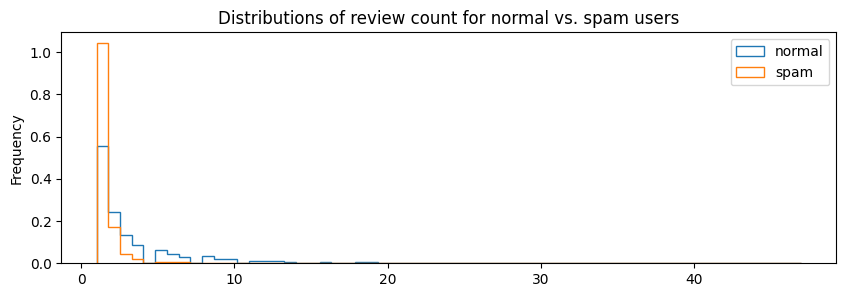

In [162]:
# TASK 3: spam users
# - do behaviour of spam users differ from normal users? consider review count
# - run this cell

def compare_feature(df, feature, user_spam_col="user_spam", figsize=(10, 3)):
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    bin_edges = np.histogram_bin_edges(yelp_chi[feature], 60)

    yelp_chi[yelp_chi[user_spam_col] == False][feature].plot.hist(bins=bin_edges, density=True, histtype="step", ax=ax)
    yelp_chi[yelp_chi[user_spam_col] == True][feature].plot.hist(bins=bin_edges, density=True, histtype="step", ax=ax)

    plt.title(f"Distributions of {" ".join(feature.split("_")[1:])} for normal vs. spam users")
    plt.legend(["normal", "spam"])
    plt.show()


yelp_chi["user_review_count"] = yelp_chi.groupby("user_id").transform("size")

compare_feature(yelp_chi, "user_review_count")

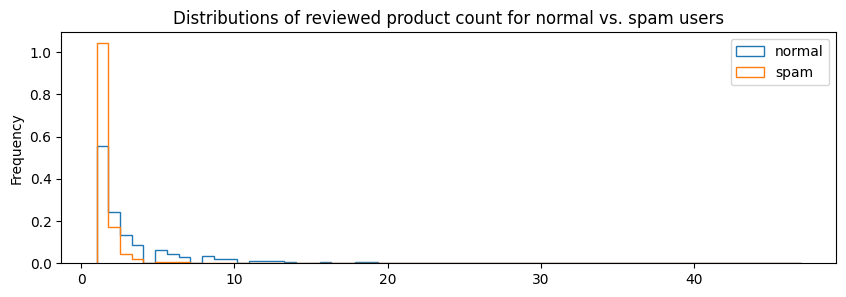

In [163]:
# TASK 3: spam users
# - do behaviour of spam users differ from normal users? consider reviewed product count
# - calculate number of unique reviewed product for each user into a new column "user_reviewed_product_count", hint: use groupby + transform
# - compare "user_reviewed_product_count" of spam vs. benign users using `compare_feature`

# TBA
#yelp_chi["user_reviewed_product_count"] = yelp_chi.groupby("user_id")["product_id"].transform("nunique")

# TBA
#compare_feature(yelp_chi, "user_reviewed_product_count")

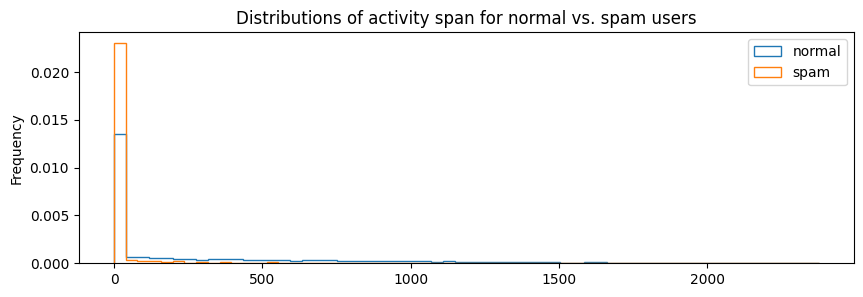

In [164]:
# TASK 3: spam users
# - do behaviour of spam users differ from normal users? consider activity span
# - run this cell

yelp_chi["user_activity_span"] = yelp_chi.groupby("user_id")["date"].transform(lambda x: x.max() - x.min()).dt.days

compare_feature(yelp_chi, "user_activity_span")

## Anomaly detection

**Classification metrics:**
* *precision*
* *recall*
* we compute macro average of metrics for normal and spam users

**Ranking metrics:**
* AUPRC - area under *precision-recall* curve, cumputed as [*average precision*](https://en.wikipedia.org/wiki/Evaluation_measures_(information_retrieval)#Average_precision)
* Rec@K - *recall* at K, where K = number of anomalies
* these metrics enable us to evaluate models while not assuming a specific classes threshold as opposed to the classification ones

### Train/test datasets

In [170]:
# TASK 5: train baseline models
# - run this cell

X_train, X_test, y_train, y_test = train_test_split(yelp_chi[FEATURES], yelp_chi["spam"].to_numpy(), test_size=0.2, stratify=yelp_chi["spam"])

### Random baseline

In [173]:
# TASK 5: train baseline models
# - run this cell
# - review metrics

clf_base = DummyClassifier(strategy="stratified")
clf_base.fit(X_train, y_train)

preds_base = clf_base.predict(X_test)
probs_base = clf_base.predict_proba(X_test)[:, 1]

metrics_base = evaluate_model(
    "baseline",
    y_test,
    preds_base,
    probs_base
)

              precision    recall  f1-score   support

           0       0.86      0.85      0.85      7856
           1       0.15      0.16      0.15      1335

    accuracy                           0.75      9191
   macro avg       0.50      0.50      0.50      9191
weighted avg       0.75      0.75      0.75      9191



,AUPRC,AUC,Rec@K
0,0.145513,0.501043,0.146816


### Random forest classifier

In [103]:
# TASK 5: train baseline models
# - train RandomForestClassifer using `X_train` and `y_train`
# - compute predicted labels (`preds_rf`) and class probabilities (`probs_rf`)
# - evaluate the model using `evaluate_model` and `X_test`/`x_train`

clf_rf = None # TBA RandomForestClassifier()
# TBA
#clf_rf.fit(X_train, y_train)

preds_rf = None # TBA clf_rf.predict(X_test)
probs_rf = None # TBA clf_rf.predict_proba(X_test)[:, 1]

metrics_rf = None # TBA evaluate_model("random_forest", y_test, preds_rf, probs_rf)

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7856
           1       0.88      0.46      0.60      1335

    accuracy                           0.91      9191
   macro avg       0.90      0.72      0.78      9191
weighted avg       0.91      0.91      0.90      9191



,AUPRC,AUC,Rec@K
0,0.781532,0.933295,0.714607


,Precision,Recall,AUPRC,Rec@K
Model,,,,
dummy,0.498106,0.498037,0.148070,0.163296
random_forest,0.895546,0.722991,0.781532,0.714607


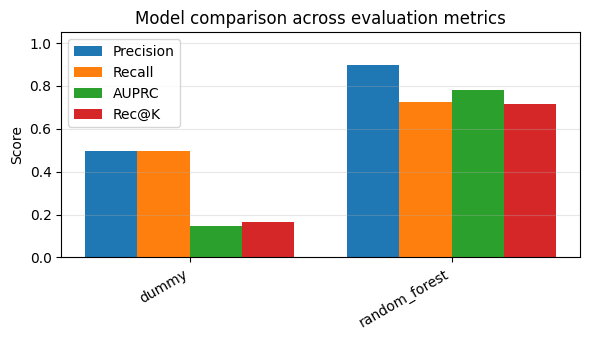

In [167]:
# TASK 5: train baseline models
# - run this cell
# - review metrics

compare_models([metrics_base, metrics_rf])